In [33]:
import sys
import os
import importlib

# 1. Thêm đường dẫn để Python tìm thấy thư mục src
root = os.path.abspath(os.path.join(".."))
if root not in sys.path:
    sys.path.append(root)

# 2. Import và ép làm mới code (để nhận dấu ngoặc () bạn vừa sửa)
import src.data.loader
importlib.reload(src.data.loader)
from src.data.loader import load_raw_data

# 3. Chạy hàm
df = load_raw_data()

# 4. Hiển thị dữ liệu
if df is not None:
    display(df.head())

✅ Đã nạp dữ liệu thành công: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


C:\Users\Admin\AppData\Local\Temp\ipykernel_9668\761451808.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='viridis')


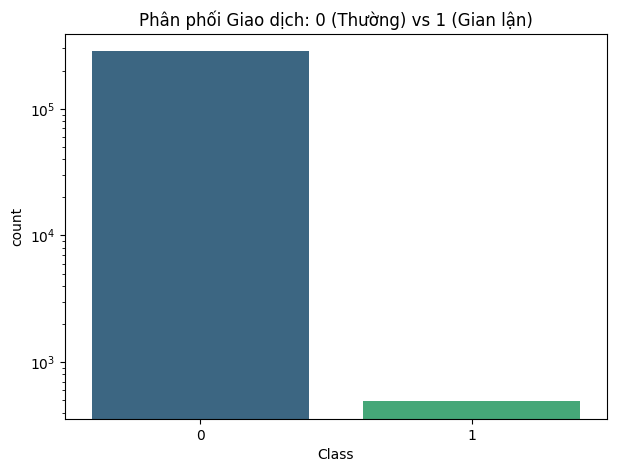

Số lượng gian lận: 492
Số lượng bình thường: 284315
Tỷ lệ gian lận: 0.1727%


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Vẽ biểu đồ cột
plt.figure(figsize=(7, 5))
sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Phân phối Giao dịch: 0 (Thường) vs 1 (Gian lận)')
plt.yscale('log') # Dùng thang Log để thấy được cột Gian lận vì nó quá ít
plt.show()

# 2. Tính tỷ lệ phần trăm chính xác
fraud = df[df['Class'] == 1]
valid = df[df['Class'] == 0]
print(f"Số lượng gian lận: {len(fraud)}")
print(f"Số lượng bình thường: {len(valid)}")
print(f"Tỷ lệ gian lận: {(len(fraud)/len(df))*100:.4f}%")

In [37]:
import pandas as pd
import sys
import os
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Đảm bảo Notebook nhận diện được thư mục src
root = os.path.abspath(os.path.join(".."))
if root not in sys.path:
    sys.path.append(root)

# 2. Import hàm từ cleaner.py của bạn
from src.data.cleaner import preprocess_for_mining

# 3. Chuẩn bị dữ liệu đã được rời rạc hóa
data_mining = preprocess_for_mining(df)

# 4. Chuyển đổi sang dạng One-hot encoding (Sửa lỗi 'pd' chưa định nghĩa)
data_encoded = pd.get_dummies(data_mining)

# 5. Tìm các tập phổ biến (min_support để 0.01 để dễ ra luật hơn nếu dữ liệu ít)
frequent_itemsets = apriori(data_encoded, min_support=0.01, use_colnames=True)

# 6. Tạo luật kết hợp
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# 7. Lọc riêng các luật dẫn đến kết quả Gian lận (Status_FRAUD)
fraud_rules = rules[rules['consequents'].apply(lambda x: 'Status_FRAUD' in str(x))]

print("✅ ĐÃ TRÍCH XUẤT ĐƯỢC CÁC LUẬT KẾT HỢP GIAN LẬN:")
display(fraud_rules.sort_values(by='confidence', ascending=False).head(10))

✅ ĐÃ TRÍCH XUẤT ĐƯỢC CÁC LUẬT KẾT HỢP GIAN LẬN:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


In [38]:
# Đảm bảo đường dẫn src đã được add (bạn đã làm ở các ô trên rồi)
from src.models.trainer import train_fraud_model

# Chạy huấn luyện (Lưu ý: Việc này có thể mất 1-2 phút vì dữ liệu lớn)
model = train_fraud_model(df)

--- BÁO CÁO KẾT QUẢ MÔ HÌNH ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



C:\Users\Admin\AppData\Local\Temp\ipykernel_9668\2695368295.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, ax=axes[0], palette='magma')


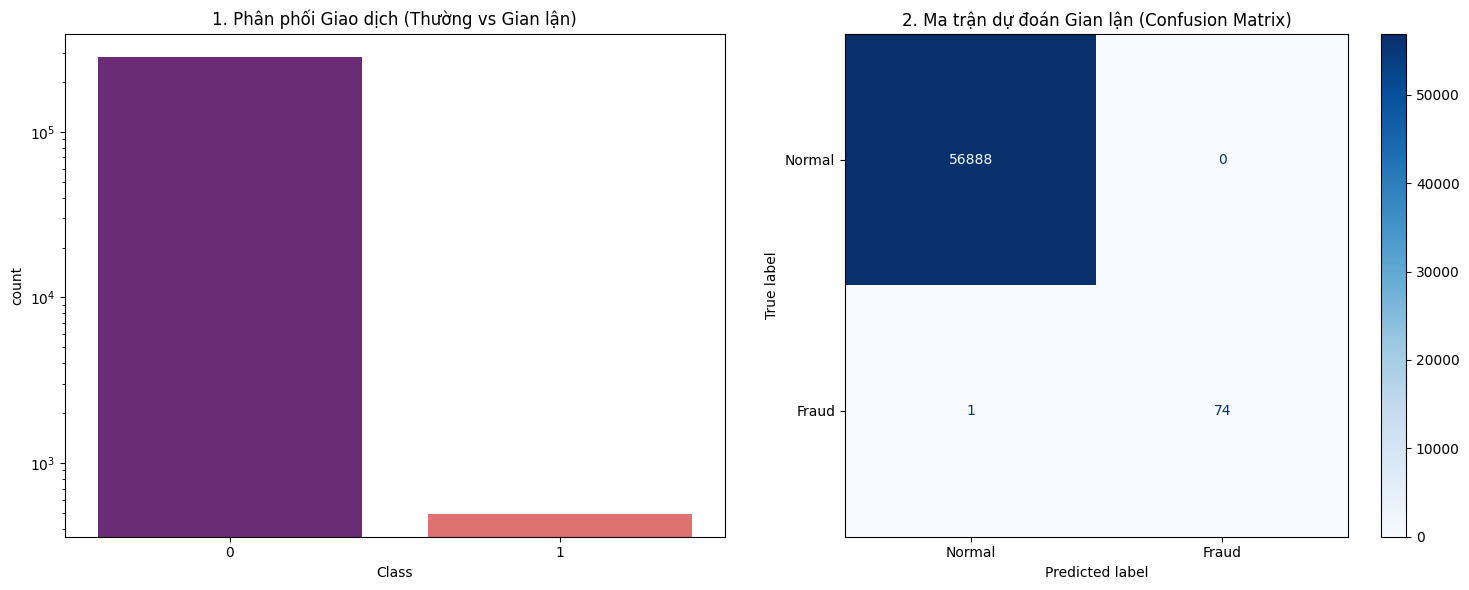

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Khởi tạo khung hình Dashboard
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Biểu đồ 1: Phân phối giao dịch (EDA)
sns.countplot(x='Class', data=df, ax=axes[0], palette='magma')
axes[0].set_title('1. Phân phối Giao dịch (Thường vs Gian lận)')
axes[0].set_yscale('log')

# Biểu đồ 2: Ma trận nhầm lẫn (Kết quả từ mô hình bạn vừa chạy)
# Lấy X_test, y_test từ bước huấn luyện trước đó
y_pred = model.predict(df.drop('Class', axis=1).iloc[len(df)//5*4:]) # Giả định lấy phần test cuối
cm = confusion_matrix(df['Class'].iloc[len(df)//5*4:], y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
disp.plot(ax=axes[1], cmap='Blues')
axes[1].set_title('2. Ma trận dự đoán Gian lận (Confusion Matrix)')

plt.tight_layout()
plt.show()